In [2]:
import os
import zipfile
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import confusion_matrix,classification_report


In [3]:
SEED=42
tf.random.set_seed(SEED)
np.random.seed(SEED)
IMG_SIZE=(128,128)
BATCH_SIZE=32
EPOCHS=20

In [4]:
BASE_DIR=Path.cwd()
TRAIN_ZIP=BASE_DIR/"train.zip"
TEST_ZIP=BASE_DIR/"test.zip"
RAW_DIR=BASE_DIR/"raw_data"
DATASET_DIR=BASE_DIR/"dataset"
TRAIN_ZIP.exists()
TEST_ZIP.exists()

True

In [5]:
if RAW_DIR.exists():
    shutil.rmtree(RAW_DIR)
RAW_DIR.mkdir(parents=True,
              exist_ok=True)
with zipfile.ZipFile(TRAIN_ZIP,'r')as zip_ref:
     zip_ref.extractall(RAW_DIR/"train")
with zipfile.ZipFile(TEST_ZIP,'r')as zip_ref:
     zip_ref.extractall(RAW_DIR/"test")
print("ZIP files extracted successfully.")


ZIP files extracted successfully.


In [6]:
classes = ["apple", "banana", "orange"]
for split in ["train", "test"]:
    for class_name in classes:
        folder_path = DATASET_DIR / split / class_name
        folder_path.mkdir(parents=True, exist_ok=True)
print("Dataset folders created successfully.")


Dataset folders created successfully.


In [14]:
def organize_images(source_dir,target_dir):
    for image_file in source_dir.glob("*"):
        if not image_file.is_file():
            continue
            file_name = image_file.name.lower()

        for class_name in classes:
            if class_name in file_name:
                destination=(target_dir/class_name/image_file.name)
                shutil.copy(image_file,destination)
                break
        
    print(f"Images organized from{source_dir}to{target_dir}")

In [15]:
organize_images(RAW_DIR / "train", DATASET_DIR / "train")
organize_images(RAW_DIR / "test", DATASET_DIR / "test")
print("Images organized successfully.")

Images organized fromC:\Users\user\Desktop\SA2\Sa4110\CA - Team Project\raw_data\traintoC:\Users\user\Desktop\SA2\Sa4110\CA - Team Project\dataset\train
Images organized fromC:\Users\user\Desktop\SA2\Sa4110\CA - Team Project\raw_data\testtoC:\Users\user\Desktop\SA2\Sa4110\CA - Team Project\dataset\test
Images organized successfully.


In [16]:
for split in["train","test"]:
    print(f"\n{split.upper()}SET")
    for class_name in classes:
        folder_path=DATASET_DIR/split/class_name
        image_count=len(list(folder_path.glob("*")))
        print(f"{class_name}:{image_count}images")


TRAINSET
apple:75images
banana:73images
orange:72images

TESTSET
apple:19images
banana:18images
orange:18images


In [17]:
train_dataset=tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR/"train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True)
test_dataset=tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR/"test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False)

Found 220 files belonging to 3 classes.
Found 55 files belonging to 3 classes.


In [18]:
class_names=train_dataset.class_names
print(class_names)

['apple', 'banana', 'orange']


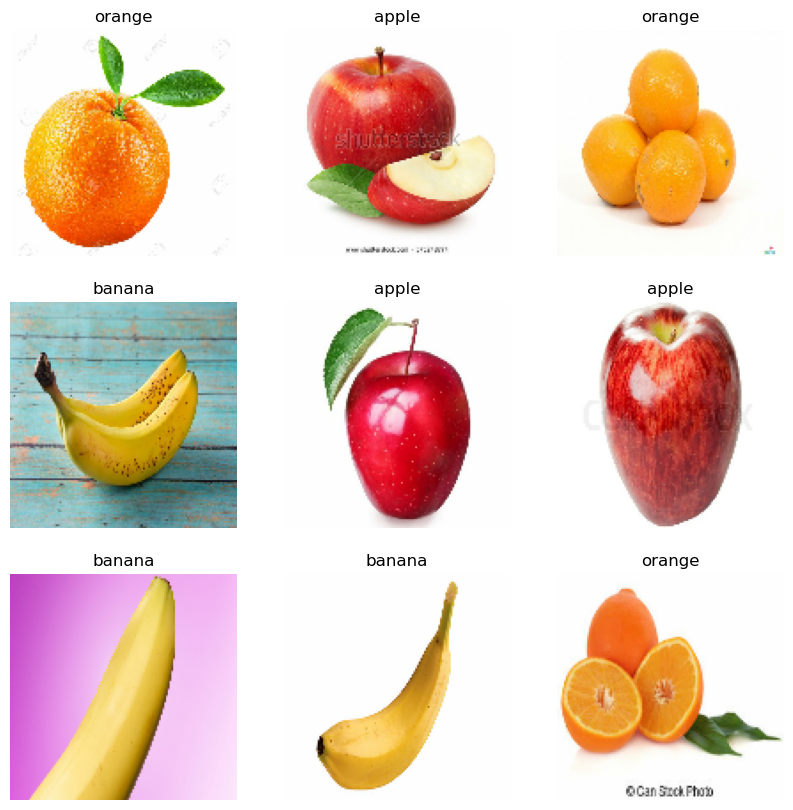

In [19]:
plt.figure(figsize=(10,10))
for images,labels in train_dataset.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.show()

In [20]:
baseline_model = keras.Sequential([
    layers.Rescaling(1./255, input_shape=(128, 128, 3)),

    layers.Conv2D(16, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64,3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
   

    layers.Dense(len(class_name), activation='softmax')
])

C:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [21]:
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 126, 126, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 12544)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       1,605,760 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,630,118 (6.22 MB)

 Trainable params: 1,630,118 (6.22 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [23]:
baseline_history = baseline_model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=EPOCHS
)


Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - accuracy: 0.4727 - loss: 1.1944 - val_accuracy: 0.6727 - val_loss: 0.7691
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.7682 - loss: 0.5899 - val_accuracy: 0.8182 - val_loss: 0.6669
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - accuracy: 0.8455 - loss: 0.3905 - val_accuracy: 0.8727 - val_loss: 0.4885
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.8909 - loss: 0.2695 - val_accuracy: 0.8364 - val_loss: 0.3926
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.9318 - loss: 0.2064 - val_accuracy: 0.9091 - val_loss: 0.3960
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.9455 - loss: 0.1470 - val_accuracy: 0.9273 - val_loss: 0.2956
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - accuracy: 0.9682 - loss: 0.1032 - val_accuracy: 0.9455 - val_loss: 0.3355
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.9773 - loss: 0.0915 - val_accuracy: 0.9455 - val_loss: 0.3028

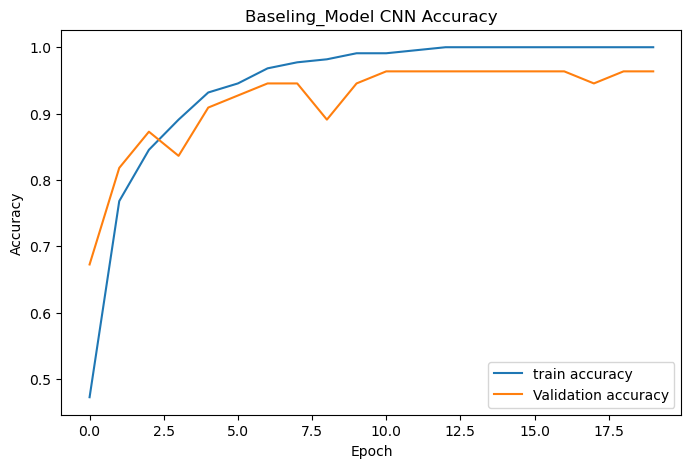

In [24]:
plt.figure(figsize=(8,5))
plt.plot(baseline_history.history['accuracy'],
        label='train accuracy')
plt.plot(baseline_history.history['val_accuracy'],
        label='Validation accuracy')

plt.title('Baseling_Model CNN Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend()

plt.show()

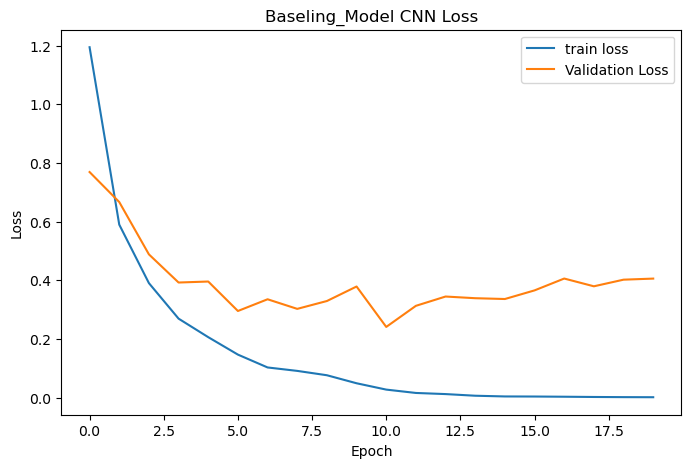

In [25]:
plt.figure(figsize=(8,5))
plt.plot(baseline_history.history['loss'],
        label='train loss')
plt.plot(baseline_history.history['val_loss'],
        label='Validation Loss')

plt.title('Baseling_Model CNN Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend()

plt.show()


In [35]:
y_true = []
y_pred = []

for images, labels in test_dataset:

    predictions = baseline_model.predict(
        images,
        verbose=0
    )

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

class_names = ['apple', 'banana', 'orange']
Number of classes = 3
Confusion Matrix Shape = (3, 3)
[[19  0  0]
 [ 1 16  1]
 [ 0  0 18]]


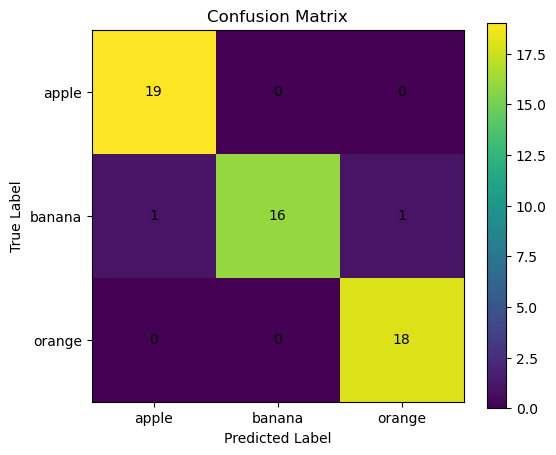

In [36]:
cm = confusion_matrix(
    y_true,
    y_pred
)
print("class_names =", class_names)
print("Number of classes =", len(class_names))

print("Confusion Matrix Shape =", cm.shape)

print(cm)
plt.figure(figsize=(6,5))

plt.imshow(cm)

plt.colorbar()

plt.xticks(
    range(len(class_names)),
    class_names
)

plt.yticks(
    range(len(class_names)),
    class_names
)

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.title("Confusion Matrix")

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(
            j,
            i,
            cm[i,j],
            ha="center",
            va="center"
        )

plt.show()


In [37]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)

              precision    recall  f1-score   support

       apple       0.95      1.00      0.97        19
      banana       1.00      0.89      0.94        18
      orange       0.95      1.00      0.97        18

    accuracy                           0.96        55
   macro avg       0.97      0.96      0.96        55
weighted avg       0.97      0.96      0.96        55



In [38]:
misclassified_images = []
misclassified_true = []
misclassified_pred = []

for images, labels in test_dataset:

    predictions = baseline_model.predict(
        images,
        verbose=0
    )

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    for i in range(len(labels)):

        if labels[i] != predicted_labels[i]:

            misclassified_images.append(
                images[i]
            )

            misclassified_true.append(
                labels[i]
            )

            misclassified_pred.append(
                predicted_labels[i]
            )

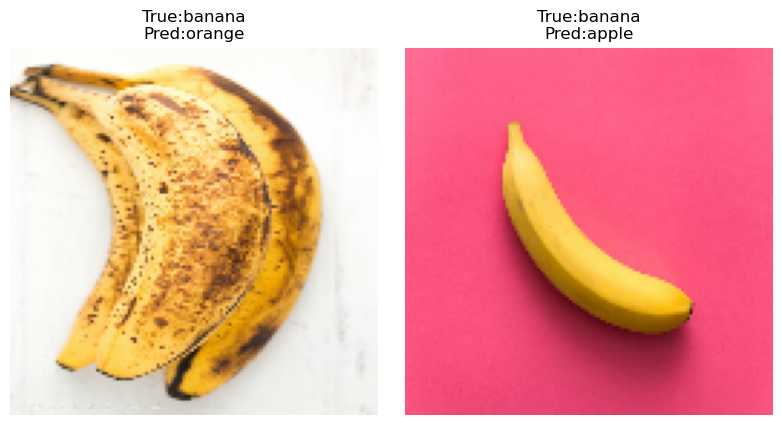

In [39]:
plt.figure(figsize=(12,12))

for i in range(
    min(
        9,
        len(misclassified_images)
    )
):

    plt.subplot(
        3,
        3,
        i+1
    )

    plt.imshow(
        misclassified_images[i].numpy().astype("uint8")
    )

    true_label = class_names[
        int(misclassified_true[i])
    ]

    pred_label = class_names[
        int(misclassified_pred[i])
    ]

    plt.title(
        f"True:{true_label}\nPred:{pred_label}"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

In [40]:
data_augmentation = keras.Sequential([

    layers.RandomFlip(
        "horizontal"
    ),

    layers.RandomRotation(
        0.1
    ),

    layers.RandomZoom(
        0.1
    )

])

In [41]:
improved_model = keras.Sequential([

    data_augmentation,

    layers.Rescaling(
        1./255,
        input_shape=(128,128,3)
    ),

    layers.Conv2D(
        32,
        3,
        activation='relu'
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        64,
        3,
        activation='relu'
    ),

    layers.MaxPooling2D(),

    layers.Conv2D(
        128,
        3,
        activation='relu'
    ),

    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(
        128,
        activation='relu'
    ),

    layers.Dropout(
        0.3
    ),

    layers.Dense(
        len(class_names),
        activation='softmax'
    )

])

C:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [42]:
improved_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)            │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling_1 (Rescaling)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [43]:
improved_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [44]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    
    monitor="val_loss",
    
    patience=3,
    
    restore_best_weights=True
    
)

In [45]:
improved_history = improved_model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=EPOCHS,
    callbacks=[early_stopping]
)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 222ms/step - accuracy: 0.4455 - loss: 1.2627 - val_accuracy: 0.3636 - val_loss: 1.0051
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 168ms/step - accuracy: 0.6591 - loss: 0.8179 - val_accuracy: 0.7818 - val_loss: 0.5538
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 161ms/step - accuracy: 0.7545 - loss: 0.5932 - val_accuracy: 0.8545 - val_loss: 0.4747
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 162ms/step - accuracy: 0.8864 - loss: 0.3350 - val_accuracy: 0.9455 - val_loss: 0.3267
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step - accuracy: 0.8818 - loss: 0.3115 - val_accuracy: 0.9455 - val_loss: 0.2321
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step - accuracy: 0.9227 - loss: 0.2670 - val_accuracy: 0.9273 - val_loss: 0.2784
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step - accuracy: 0.9409 - loss: 0.2027 - val_accuracy: 0.9273 - val_loss: 0.1640
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 165ms/step - accuracy: 0.9636 - loss: 0.1331 - val_accuracy: 0.9273 - val_loss:

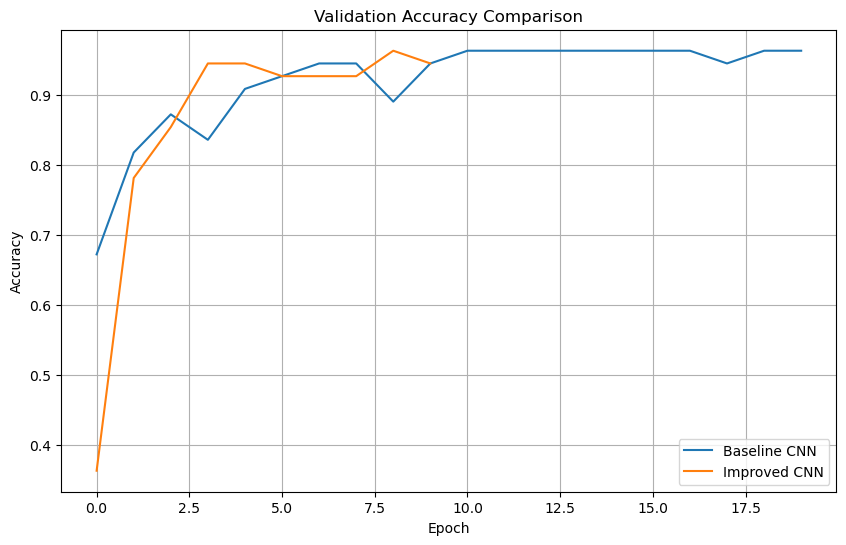

In [46]:
plt.figure(figsize=(10,6))

plt.plot(
    baseline_history.history['val_accuracy'],
    label='Baseline CNN'
)

plt.plot(
    improved_history.history['val_accuracy'],
    label='Improved CNN'
)

plt.title(
    'Validation Accuracy Comparison'
)

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend()

plt.grid()

plt.show()

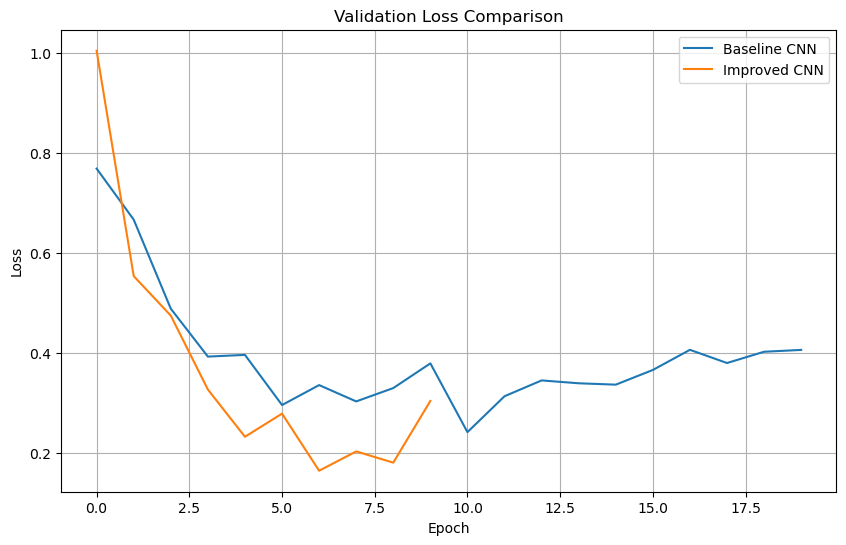

In [47]:
plt.figure(figsize=(10,6))

plt.plot(
    baseline_history.history['val_loss'],
    label='Baseline CNN'
)

plt.plot(
    improved_history.history['val_loss'],
    label='Improved CNN'
)

plt.title(
    'Validation Loss Comparison'
)

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend()

plt.grid()

plt.show()

In [48]:
y_true_improved = []
y_pred_improved = []

for images, labels in test_dataset:

    predictions = improved_model.predict(
        images,
        verbose=0
    )

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    y_true_improved.extend(
        labels.numpy()
    )

    y_pred_improved.extend(
        predicted_labels
    )

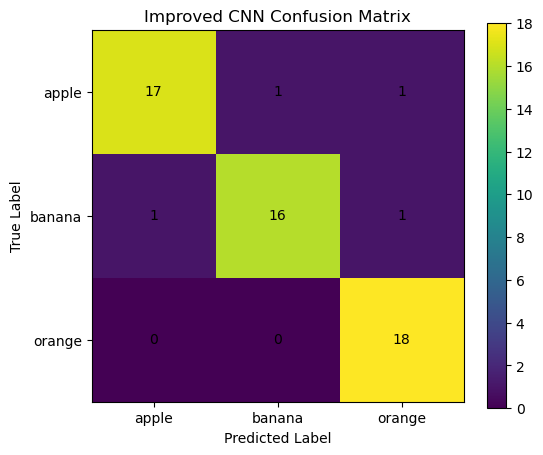

In [49]:
cm_improved = confusion_matrix(
    y_true_improved,
    y_pred_improved
)

plt.figure(figsize=(6,5))

plt.imshow(cm_improved)

plt.colorbar()

plt.xticks(
    range(len(class_names)),
    class_names
)

plt.yticks(
    range(len(class_names)),
    class_names
)

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.title("Improved CNN Confusion Matrix")

for i in range(len(class_names)):
    
    for j in range(len(class_names)):
        
        plt.text(
            j,
            i,
            cm_improved[i,j],
            ha="center",
            va="center"
        )

plt.show()

In [50]:
report_improved = classification_report(
    y_true_improved,
    y_pred_improved,
    target_names=class_names
)

print(report_improved)

              precision    recall  f1-score   support

       apple       0.94      0.89      0.92        19
      banana       0.94      0.89      0.91        18
      orange       0.90      1.00      0.95        18

    accuracy                           0.93        55
   macro avg       0.93      0.93      0.93        55
weighted avg       0.93      0.93      0.93        55



In [54]:
baseline_best_acc = max(
    baseline_history.history['val_accuracy']
)

improved_best_acc = max(
    improved_history.history['val_accuracy']
)

baseline_last_acc = baseline_history.history['val_accuracy'][-1]

improved_last_acc = improved_history.history['val_accuracy'][-1]

baseline_epochs = len(
    baseline_history.history['val_accuracy']
)

improved_epochs = len(
    improved_history.history['val_accuracy']
)

print("Model Comparison")
print("----------------------------")
print(f"Baseline CNN Best Validation Accuracy : {baseline_best_acc:.4f}")
print(f"Improved CNN Best Validation Accuracy : {improved_best_acc:.4f}")
print()
print(f"Baseline CNN Last Validation Accuracy : {baseline_last_acc:.4f}")
print(f"Improved CNN Last Validation Accuracy : {improved_last_acc:.4f}")
print()
print(f"Baseline CNN Epochs : {baseline_epochs}")
print(f"Improved CNN Epochs : {improved_epochs}")

Model Comparison
----------------------------
Baseline CNN Best Validation Accuracy : 0.9636
Improved CNN Best Validation Accuracy : 0.9636

Baseline CNN Last Validation Accuracy : 0.9636
Improved CNN Last Validation Accuracy : 0.9455

Baseline CNN Epochs : 20
Improved CNN Epochs : 10


In [52]:
print("Baseline:")
print(baseline_history.history['val_accuracy'])

print()

print("Improved:")
print(improved_history.history['val_accuracy'])

Baseline:
[0.6727272868156433, 0.8181818127632141, 0.8727272748947144, 0.8363636136054993, 0.9090909361839294, 0.9272727370262146, 0.9454545378684998, 0.9454545378684998, 0.8909090757369995, 0.9454545378684998, 0.9636363387107849, 0.9636363387107849, 0.9636363387107849, 0.9636363387107849, 0.9636363387107849, 0.9636363387107849, 0.9636363387107849, 0.9454545378684998, 0.9636363387107849, 0.9636363387107849]

Improved:
[0.3636363744735718, 0.7818182110786438, 0.8545454740524292, 0.9454545378684998, 0.9454545378684998, 0.9272727370262146, 0.9272727370262146, 0.9272727370262146, 0.9636363387107849, 0.9454545378684998]
